In [1]:
# !unzip MSLR-WEB10K.zip

In [2]:
import pandas as pd
import numpy as np
import sklearn
from sklearn.datasets import load_svmlight_file
import os

In [8]:
def load_fold_data(fold_path):
    print(f'Load data from {fold_path}')

    X_train, y_train, qid_train = load_svmlight_file(os.path.join(fold_path, 'train.txt'), query_id=True)
    X_val, y_val, qid_val = load_svmlight_file(os.path.join(fold_path, 'vali.txt'), query_id=True)
    X_test, y_test, qid_test = load_svmlight_file(os.path.join(fold_path, 'test.txt'), query_id=True)
    
    return (X_train, y_train, qid_train), (X_val, y_val, qid_val), (X_test, y_test, qid_test)

train, val, test = load_fold_data('Fold1')
X_train, y_train, qid_train = train
X_val, y_val, qid_val = val
X_test, y_test, qid_test = val

Load data from Fold1


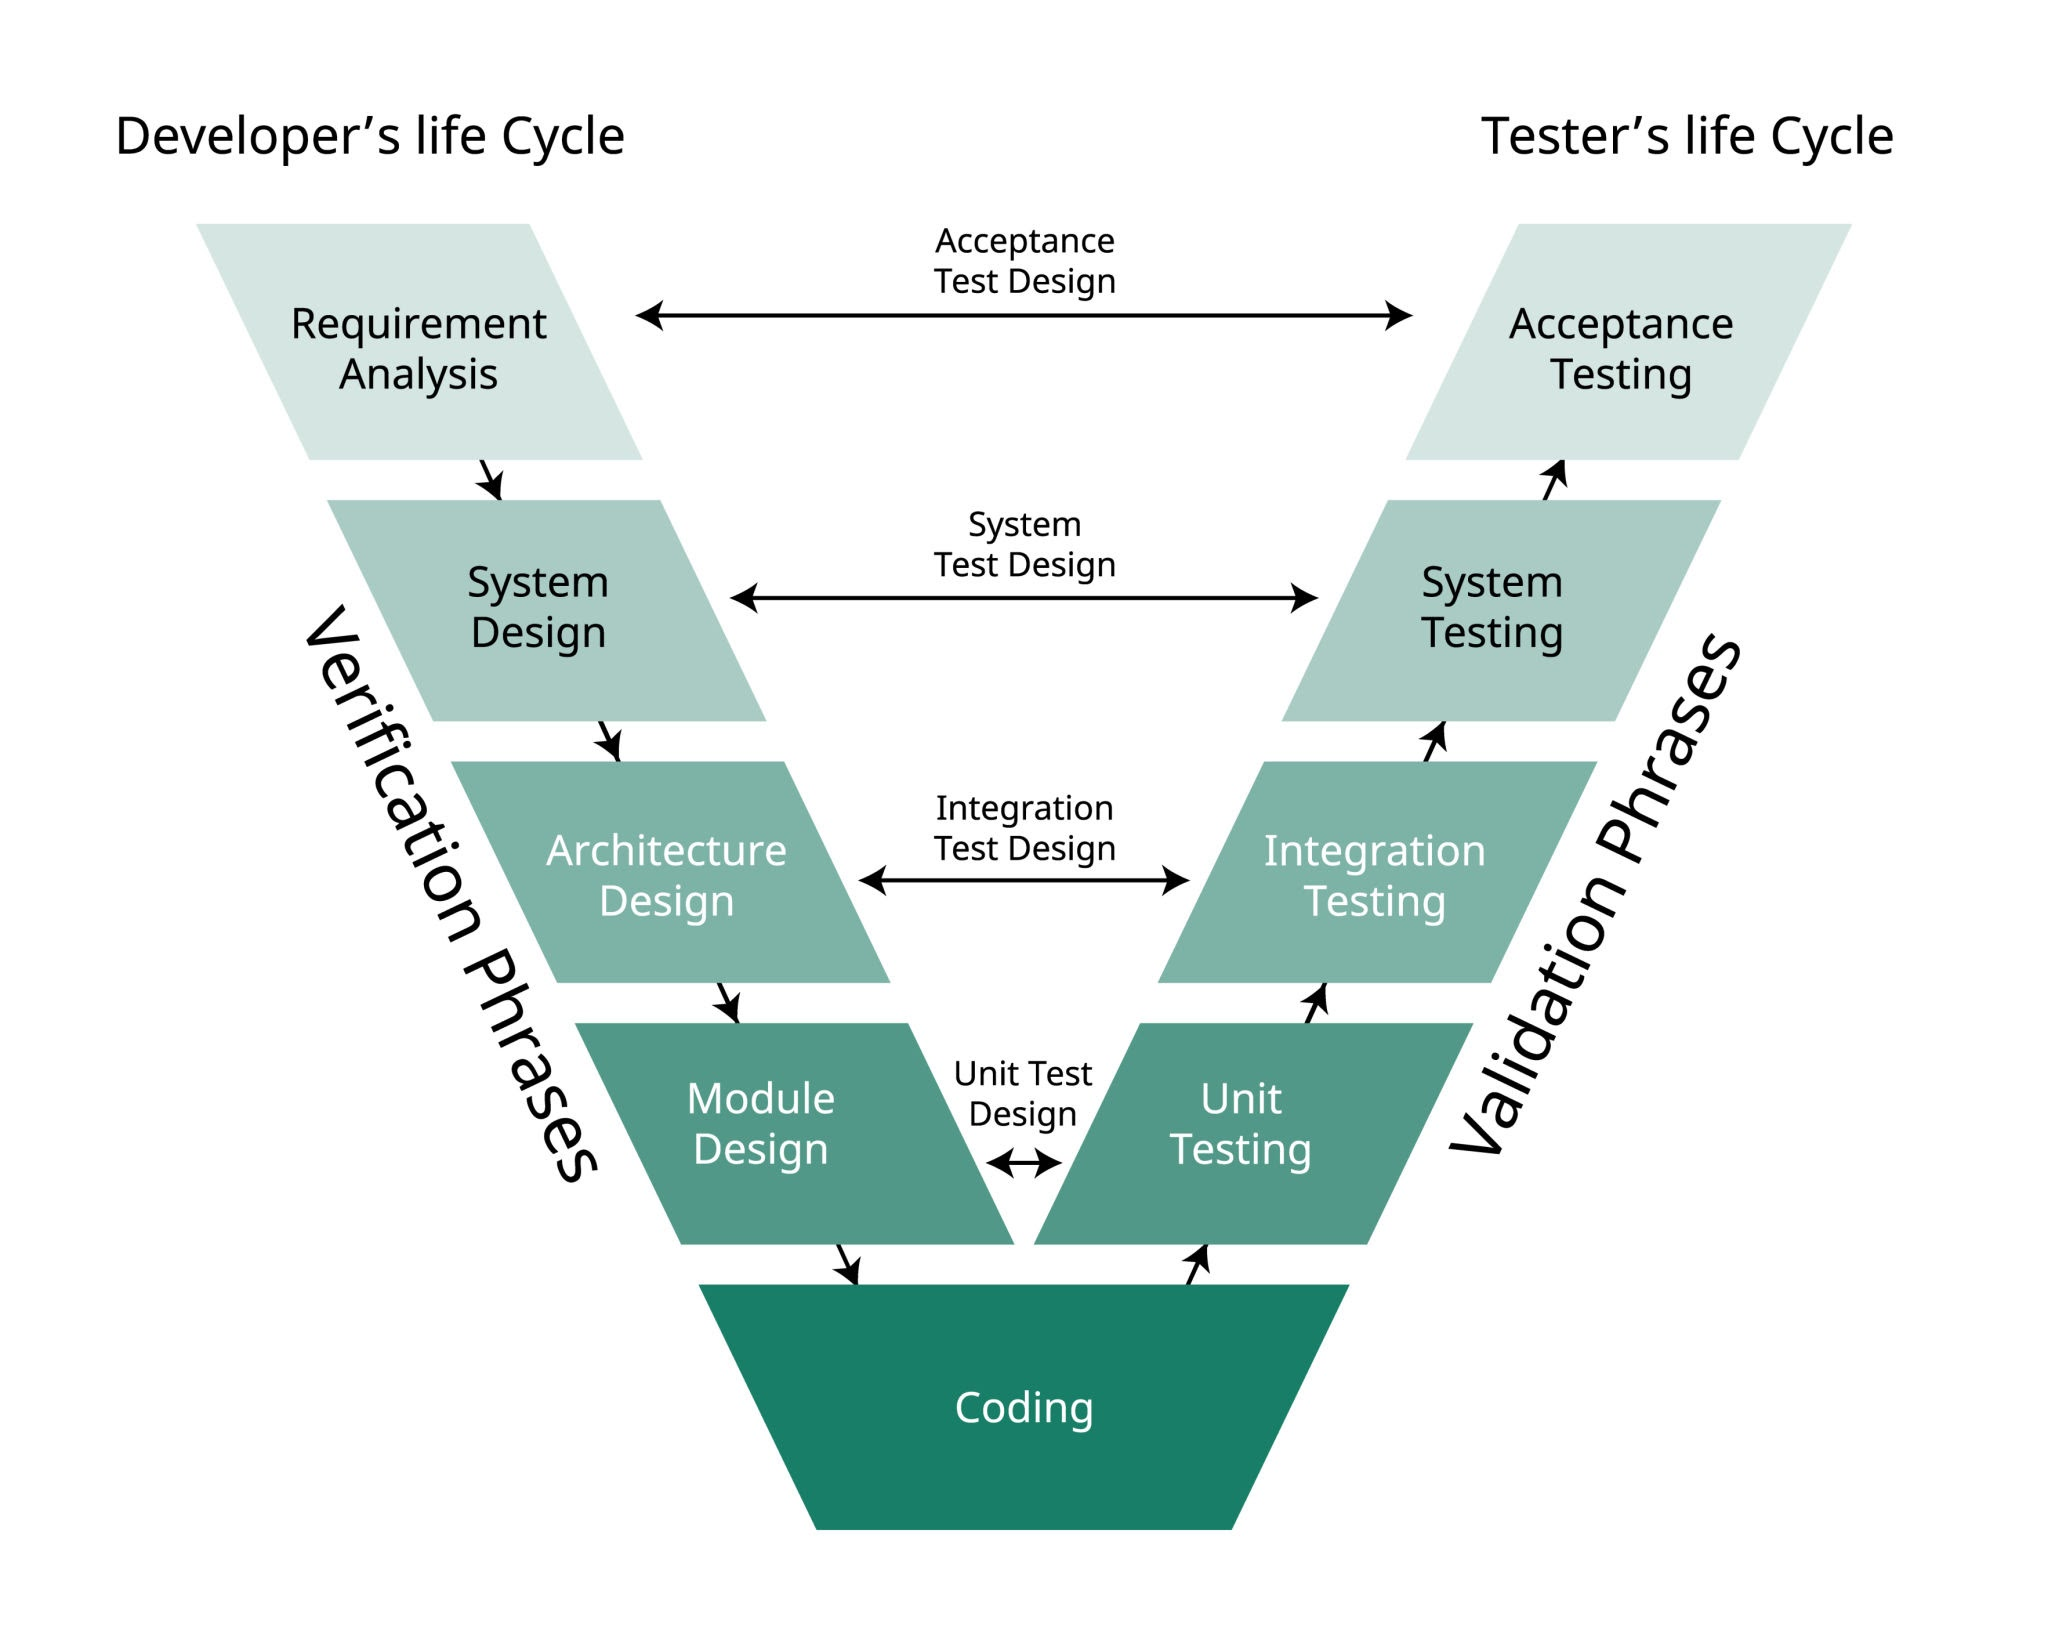

In [4]:
def get_data_from_fold(fold_number):
    """Загружает данные конкретного фолда (1-5)."""
    base_path = f'Fold{fold_number}/'
    
    # Загружаем файлы
    X_train, y_train, qid_train = load_svmlight_file(base_path + 'train.txt', query_id=True)
    X_val, y_val, qid_val = load_svmlight_file(base_path + 'vali.txt', query_id=True)
    X_test, y_test, qid_test = load_svmlight_file(base_path + 'test.txt', query_id=True)
    
    return {
        'train': (X_train, y_train, qid_train),
        'val': (X_val, y_val, qid_val),
        'test': (X_test, y_test, qid_test)
    }

# fold1 = get_data_from_fold(1) 

In [14]:
u_quids, group_counts = np.unique(qid_train, return_counts=True)
u_quids, group_counts_test = np.unique(qid_test, return_counts=True)

print(group_counts[:5])
print(np.sum(group_counts) == len(qid_train))

[ 86 103 111 106  76]
True


In [6]:
from xgboost import XGBRanker

model = XGBRanker(
    objective='rank:pairwise',
    n_estimators=100,
    learning_rate=.1,
    tree_method='hist'
)

model.fit(X_train, y_train, group=group_counts)

XGBRanker(base_score=None, booster=None, callbacks=None, colsample_bylevel=None,
          colsample_bynode=None, colsample_bytree=None, device=None,
          early_stopping_rounds=None, enable_categorical=False,
          eval_metric=None, feature_types=None, feature_weights=None,
          gamma=None, grow_policy=None, importance_type=None,
          interaction_constraints=None, learning_rate=0.1, max_bin=None,
          max_cat_threshold=None, max_cat_to_onehot=None, max_delta_step=None,
          max_depth=None, max_leaves=None, min_child_weight=None, missing=nan,
          monotone_constraints=None, multi_strategy=None, n_estimators=100,
          n_jobs=None, num_parallel_tree=None, ...)

In [9]:
from catboost import CatBoostRanker, Pool

train_pool = Pool(data=X_train, label=y_train, group_id=qid_train)
val_pool = Pool(data=X_val, label=y_val, group_id=qid_val)

cat_model = CatBoostRanker(
    loss_function='YetiRank',
    iterations=100,
    learning_rate=.1,
)

cat_model.fit(train_pool, eval_set=val_pool, verbose=False)

In [10]:
preds_xgb = model.predict(X_test)
preds_cat = cat_model.predict(X_test)

In [15]:
indices = np.cumsum(group_counts_test)[:-1]

y_test_grouped = np.split(y_test, indices)
preds_xgb_grouped = np.split(preds_xgb, indices)
preds_cat_grouped = np.split(preds_cat, indices)

In [27]:
from sklearn.metrics import ndcg_score

def calculate_ndcg(y_grouped, preds_grouped, k=10):
    scores = []
    for y_true, y_pred in zip(y_grouped, preds_grouped):
        # Если в группе только один документ или все оценки одинаковые, 
        # IDCG будет равен 0, и sklearn может выдать ошибку или 0.
        # Мы считаем только те группы, где есть хотя бы одна ненулевая оценка.
        if len(y_true) > 1 and np.sum(y_true) > 0:
            # ndcg_score ожидает 2D массивы (batch_size, n_samples)
            score = ndcg_score([y_true], [y_pred], k=k)
            scores.append(score)
    return np.mean(scores)

# Считаем для обеих моделей
ndcg_xgb = calculate_ndcg(y_test_grouped, preds_xgb_grouped, k=10)
ndcg_cat = calculate_ndcg(y_test_grouped, preds_cat_grouped, k=10)

print(f"XGBoost NDCG@10: {ndcg_xgb:.4f}")
print(f"CatBoost NDCG@10: {ndcg_cat:.4f}")

XGBoost NDCG@10: 0.5623
CatBoost NDCG@10: 0.5620


<Figure size 1000x800 with 0 Axes>

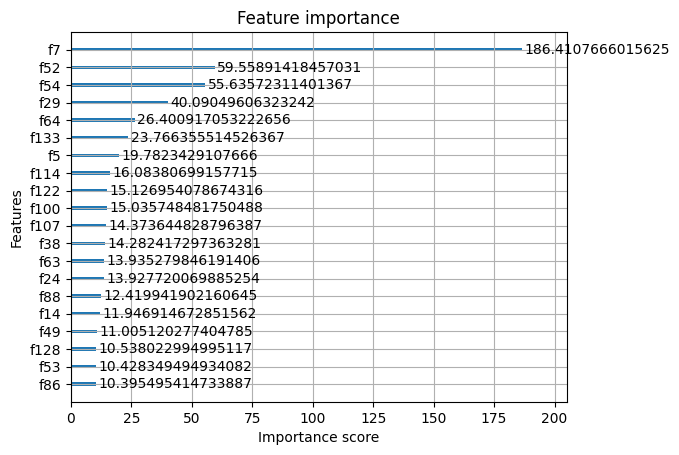

In [17]:
import matplotlib.pyplot as plt
from xgboost import plot_importance

# Увеличим размер графика, чтобы названия признаков были читаемы
plt.figure(figsize=(10, 8))

# Параметр importance_type='gain' покажет самые "полезные" признаки
plot_importance(model, max_num_features=20, importance_type='gain')
plt.show()

In [20]:
!pip install optuna -q

In [22]:
import optuna
from xgboost import XGBRanker

def objective(trial):
    # 1. Определяем пространство поиска гиперпараметров 
    param = {
        'objective': 'rank:pairwise',
        'tree_method': 'hist',
        'n_estimators': trial.suggest_int('n_estimators', 50, 200),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
    }

    # 2. Инициализируем и обучаем модель на одном фолде
    model = XGBRanker(**param)
    # Используем данные нашего контрольного фолда
    model.fit(X_train, y_train, group=group_counts)

    # 3. Делаем предсказания и считаем метрику
    preds = model.predict(X_val)
    
    # Группируем предсказания для расчета NDCG
    # (используем точки раздела, которые мы подготовили ранее через np.split)
    preds_grouped = np.split(preds, indices_val)
    y_val_grouped = np.split(y_val, indices_val)
    
    score = calculate_ndcg(y_val_grouped, preds_grouped, k=10)
    
    return score

# Создаем исследование и запускаем поиск
# 1. Считаем количество документов в каждой группе для ВАЛИДАЦИОННОГО набора
u_qids_val, group_counts_val = np.unique(qid_val, return_counts=True)

# 2. Создаем точки раздела (индексы) для np.split
# Мы используем [:-1], потому что последний индекс split не нужен
indices_val = np.cumsum(group_counts_val)[:-1]

# Теперь можно запускать оптимизацию
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30)

print(f"Лучший результат: {study.best_value:.4f}")
print("Лучшие параметры:", study.best_params)

[I 2026-01-31 02:46:54,746] A new study created in memory with name: no-name-52ff0769-b20d-46d8-a38d-43defae5f3a6
[I 2026-01-31 02:47:04,906] Trial 0 finished with value: 0.5456927359782894 and parameters: {'n_estimators': 122, 'learning_rate': 0.10093615379141357, 'max_depth': 3, 'subsample': 0.96089969748188, 'colsample_bytree': 0.7061147673111074}. Best is trial 0 with value: 0.5456927359782894.
[I 2026-01-31 02:47:26,536] Trial 1 finished with value: 0.5593253952419417 and parameters: {'n_estimators': 139, 'learning_rate': 0.07467214502726617, 'max_depth': 10, 'subsample': 0.7156421832858217, 'colsample_bytree': 0.7927886340780328}. Best is trial 1 with value: 0.5593253952419417.
[I 2026-01-31 02:47:46,490] Trial 2 finished with value: 0.5608820300936725 and parameters: {'n_estimators': 124, 'learning_rate': 0.023599736114891082, 'max_depth': 9, 'subsample': 0.8073651160724413, 'colsample_bytree': 0.9975036365156813}. Best is trial 2 with value: 0.5608820300936725.
[I 2026-01-31 02

Лучший результат: 0.5677
Лучшие параметры: {'n_estimators': 180, 'learning_rate': 0.07509448525142452, 'max_depth': 7, 'subsample': 0.9242076361698963, 'colsample_bytree': 0.9443236526860964}


In [28]:
import numpy as np
import pandas as pd
from xgboost import XGBRanker
from sklearn.datasets import load_svmlight_file # Оптимально для формата MSLR

# 1. Ваши лучшие параметры из Optuna
best_params = {
    'objective': 'rank:pairwise',
    'tree_method': 'hist',
    'n_estimators': 180,
    'learning_rate': 0.07509448525142452,
    'max_depth': 7,
    'subsample': 0.9242076361698963,
    'colsample_bytree': 0.9443236526860964,
    'random_state': 42
}

def load_mslr_file(path):
    """Загрузка данных в формате svmlight (стандарт для MSLR)"""
    data = load_svmlight_file(path, query_id=True)
    return data[0], data[1], data[2] # X, y, qids

def run_full_cv(base_path):
    cv_scores = []
    
    # Проходим по каждому фолду как по тестовому
    for test_idx in range(1, 6):
        print(f"🚀 Обработка итерации {test_idx}: Тест = Fold{test_idx}")
        
        # Загружаем тестовый набор
        test_path = f"{base_path}/Fold{test_idx}/test.txt"
        X_test, y_test, qids_test = load_mslr_file(test_path)
        
        # Загружаем и объединяем остальные фолды для обучения
        X_train_list, y_train_list, qids_train_list = [], [], []
        
        for train_idx in range(1, 6):
            if train_idx == test_idx:
                continue
            
            # В MSLR обычно обучаются на train.txt из каждого фолда
            train_path = f"{base_path}/Fold{train_idx}/train.txt"
            xt, yt, qt = load_mslr_file(train_path)
            X_train_list.append(xt)
            y_train_list.append(yt)
            qids_train_list.append(qt)
            
        # Объединяем тренировочные данные
        from scipy.sparse import vstack
        X_train = vstack(X_train_list)
        y_train = np.concatenate(y_train_list)
        qids_train = np.concatenate(qids_train_list)
        
        # Группировка для XGBoost (важно: данные должны быть отсортированы по qid)
        _, train_groups = np.unique(qids_train, return_counts=True)
        _, test_groups = np.unique(qids_test, return_counts=True)
        
        # Обучение модели
        model = XGBRanker(**best_params)
        model.fit(X_train, y_train, group=train_groups)
        
        # Предсказание и расчет NDCG
        preds = model.predict(X_test)
        
        # Подготовка групп для вашей функции calculate_ndcg
        indices_test = np.cumsum(test_groups)[:-1]
        y_test_grouped = np.split(y_test, indices_test)
        preds_grouped = np.split(preds, indices_test)
        
        fold_score = calculate_ndcg(y_test_grouped, preds_grouped, k=10)
        cv_scores.append(fold_score)
        
        print(f"✅ Fold {test_idx} NDCG@10: {fold_score:.4f}")

    print("-" * 30)
    print(f"📊 Итоговый средний NDCG@10: {np.mean(cv_scores):.4f} (+/- {np.std(cv_scores):.4f})")
    return cv_scores

# Запуск (замените путь на ваш)
scores = run_full_cv('.')

🚀 Обработка итерации 1: Тест = Fold1
✅ Fold 1 NDCG@10: 0.6025
🚀 Обработка итерации 2: Тест = Fold2
✅ Fold 2 NDCG@10: 0.6025
🚀 Обработка итерации 3: Тест = Fold3
✅ Fold 3 NDCG@10: 0.5993
🚀 Обработка итерации 4: Тест = Fold4
✅ Fold 4 NDCG@10: 0.6070
🚀 Обработка итерации 5: Тест = Fold5
✅ Fold 5 NDCG@10: 0.6095
------------------------------
📊 Итоговый средний NDCG@10: 0.6042 (+/- 0.0036)
